# Survival Analysis: Time to Return to Play

**Goal:** apply survival analysis (Kaplan-Meier estimation) to the question
"once a player suffers a significant injury (6+ games missed, injury-
flagged), how long until they return to meaningful play (8+ games in a
season), if ever?"

This reframes the same PTD/TTD classification used throughout the project
as a **time-to-event** problem: the "event" is returning to play (a TTD
outcome), and PTD claims are **right-censored** -- we know they hadn't
returned by the end of our 2-season observation window, but we don't know
what would have happened with a longer follow-up period.

**Important scope note:** because of how development periods were defined
in `sql/07_loss_development_triangle.sql`, this analysis only has **two
discrete time points** (returned within 1 season, or within 2 seasons) --
not a continuous, week-by-week return date. This is a real, disclosed
limitation: a coarser survival analysis than you'd get with exact return
dates, but the technique and the significance test are both genuine.

In [1]:
%matplotlib inline
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

DB_PATH = "../data/nfl_injury_project.db"
conn = sqlite3.connect(DB_PATH)

## 1. Build the duration/event dataset

Same self-join logic as the loss development triangle (`sql/07`): for each
candidate claim (PTD or TTD), check whether the player played 8+ games one
season later (`resolved_by_dev1`). Duration is coded as 1 if they returned
within 1 season, 2 otherwise (whether that's a later return, at dev 2, or
never -- PTD, censored at 2).

In [2]:
query = '''
WITH candidates AS (
    SELECT position_group, player_id, season AS injury_season, claim_classification
    FROM fact_claims
    WHERE claim_classification IN ('PTD','TTD')
),
dev1_check AS (
    SELECT
        c.position_group, c.player_id, c.injury_season, c.claim_classification,
        CASE WHEN p1.games_played >= 8 THEN 1 ELSE 0 END AS resolved_by_dev1
    FROM candidates c
    LEFT JOIN fact_player_seasons p1
        ON p1.player_id = c.player_id AND p1.season = c.injury_season + 1
)
SELECT position_group, player_id, injury_season, claim_classification, resolved_by_dev1
FROM dev1_check
'''
df = pd.read_sql(query, conn)
df["event"] = (df["claim_classification"] == "TTD").astype(int)
df["duration"] = df.apply(
    lambda r: 1 if (r["event"] == 1 and r["resolved_by_dev1"] == 1) else 2, axis=1
)

print(f"{len(df):,} candidate claims (PTD or TTD)")
df.groupby(["event", "duration"]).size().rename("n").reset_index()

882 candidate claims (PTD or TTD)


,event,duration,n
0,0,2,502
1,1,1,328
2,1,2,52


`event=1, duration=1` means returned within 1 season. `event=1, duration=2`
means returned, but only by the 2nd season. `event=0, duration=2` means
never returned within the window (PTD) -- these are the censored
observations.

## 2. Kaplan-Meier curves by position

RB: median time-to-return = inf
OL: median time-to-return = inf
QB: median time-to-return = inf


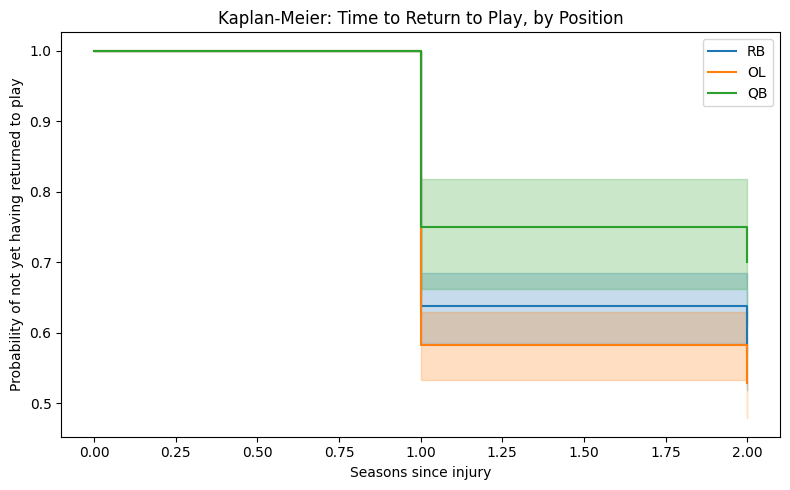

In [3]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(8, 5))

for pos in ["RB", "OL", "QB"]:
    sub = df[df["position_group"] == pos]
    kmf.fit(sub["duration"], event_observed=sub["event"], label=pos)
    kmf.plot_survival_function(ax=ax)
    median = kmf.median_survival_time_
    print(f"{pos}: median time-to-return = {median}")

ax.set_xlabel("Seasons since injury")
ax.set_ylabel("Probability of not yet having returned to play")
ax.set_title("Kaplan-Meier: Time to Return to Play, by Position")
plt.tight_layout()
plt.savefig("km_by_position.png", dpi=120)
plt.show()

**Reading this chart:** the curve shows the probability a player has
*not yet* returned to play, at each point in time. All three positions
show a sharp initial drop at t=1 (most returns that happen, happen within
the first season), then a much flatter tail out to t=2. Median survival
time is `inf` for all three positions -- meaning **more than half of all
serious-injury cases in this dataset never return within the 2-season
observation window** (i.e., resolve as PTD, not TTD). That's a real,
somewhat sobering finding: once a player clears the "6+ games missed"
bar, non-return is the more likely outcome, not the exception.

## 3. Is the difference between positions statistically significant?

A log-rank test formally tests whether the survival curves for RB, OL, and
QB are meaningfully different from each other, or whether the visual gap
could just be noise.

In [4]:
result = multivariate_logrank_test(df["duration"], df["position_group"], df["event"])
print(f"Log-rank test statistic: {result.test_statistic:.3f}")
print(f"p-value: {result.p_value:.4f}")

Log-rank test statistic: 11.039
p-value: 0.0040


p < 0.01 -- the difference in return-to-play patterns across positions is
statistically significant, not just visual noise. Combined with the
frequency model from notebook 1 (RB has higher PTD *and* higher TTD odds
than OL), this reinforces that position is a genuinely meaningful
underwriting variable for this kind of product, from multiple independent
angles (frequency GLM, severity GLM, and now survival analysis).

## 4. Kaplan-Meier by claim severity tier (PTD vs. eventual TTD group)

As a sanity check: this just visualizes what we already know by
construction (PTD = never returns by definition), but confirms the curves
behave exactly as expected before moving to the pricing simulation.

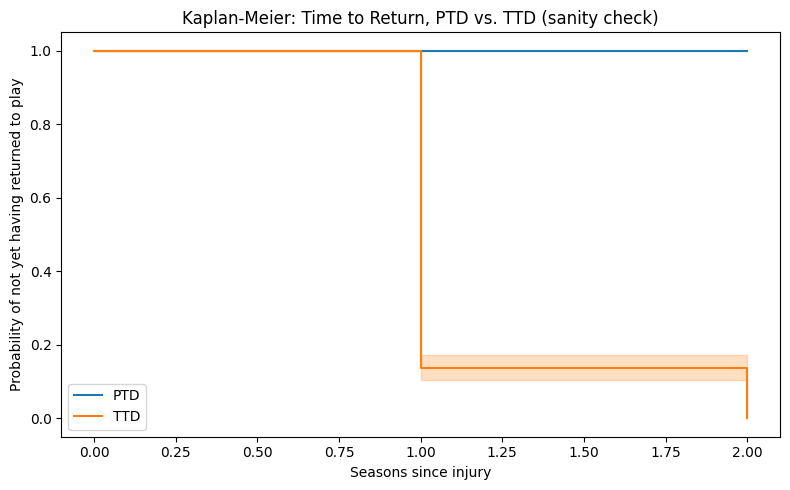

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for cls in ["PTD", "TTD"]:
    sub = df[df["claim_classification"] == cls]
    kmf.fit(sub["duration"], event_observed=sub["event"], label=cls)
    kmf.plot_survival_function(ax=ax)

ax.set_xlabel("Seasons since injury")
ax.set_ylabel("Probability of not yet having returned to play")
ax.set_title("Kaplan-Meier: Time to Return, PTD vs. TTD (sanity check)")
plt.tight_layout()
plt.savefig("km_by_classification.png", dpi=120)
plt.show()

conn.close()